# Comparativa de modelos - Clasificación

Objetivo: comparar dos versiones de cada modelo de clasificación (excepto la red bayesiana) usando validación cruzada y un conjunto holdout sobre Titanic.

## 1) Librerías

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn


In [1]:
# Importamos las bibliotecas principales del flujo de trabajo.
# La comparación completa se apoya en sklearn para preprocesamiento, validación cruzada y métricas.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import get_scorer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier


## 2) Cargar datos

In [2]:
# Leemos el dataset y revisamos su estructura antes de modelar.
data = pd.read_csv("titanic.csv")
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# info() permite ver tipos de datos, faltantes y tamaño del dataset.
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 3) Preparar datos

In [5]:
# Definimos explícitamente qué columnas entran al modelo.
# Mantener esta lista visible ayuda a que el alumno entienda qué decisiones de diseño estamos tomando.
variables_a_descartar = ["PassengerId", "Name", "Cabin", "Ticket"]
variables_categoricas = ["Sex", "Embarked"]
variables_numericas = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
variable_dependiente = "Survived"

X = data.drop([variable_dependiente] + variables_a_descartar, axis=1)
y = data[variable_dependiente].astype(int)

print(X.head())
print(y.head())


   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


## 4) Definir holdout y métricas

In [7]:
# Primero reservamos un holdout.
# La validación cruzada se hará SOLO dentro del conjunto de entrenamiento.
random_state = 42
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=random_state, stratify=y
)

# El alumno puede cambiar estas dos métricas desde la lista disponible.
metricas_disponibles = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metricas_seleccionadas = ["accuracy", "roc_auc"]

for metrica in metricas_seleccionadas:
    if metrica not in metricas_disponibles:
        raise ValueError(f"La métrica {metrica} no está en la lista disponible")

scoring = {metrica: metrica for metrica in metricas_seleccionadas}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)


## 5) Grilla de comparación

In [8]:
# Definimos un preprocesamiento común para todos los modelos.
# Esto imita la lógica que ya usamos en los notebooks de clasificación.
preprocesamiento = ColumnTransformer([
    (
        "numerico",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        variables_numericas,
    ),
    (
        "categorico",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        variables_categoricas,
    ),
])

# La grilla no busca todos los hiperparámetros posibles.
# Aquí comparamos dos versiones razonables de cada modelo para discutir diferencias de desempeño.
comparison_grid = [
    {"modelo": "KNN", "version": "k=5", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", KNeighborsClassifier(n_neighbors=5))])},
    {"modelo": "KNN", "version": "k=11", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", KNeighborsClassifier(n_neighbors=11))])},
    {"modelo": "Regresión logística", "version": "C=0.5", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", LogisticRegression(C=0.5, max_iter=1000, random_state=random_state))])},
    {"modelo": "Regresión logística", "version": "C=2.0", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", LogisticRegression(C=2.0, max_iter=1000, random_state=random_state))])},
    {"modelo": "Árbol de decisión", "version": "max_depth=4", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", DecisionTreeClassifier(max_depth=4, random_state=random_state))])},
    {"modelo": "Árbol de decisión", "version": "max_depth=8", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", DecisionTreeClassifier(max_depth=8, random_state=random_state))])},
    {"modelo": "Random forest", "version": "200 árboles, max_depth=8", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", RandomForestClassifier(n_estimators=200, max_depth=8, random_state=random_state))])},
    {"modelo": "Random forest", "version": "400 árboles", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", RandomForestClassifier(n_estimators=400, random_state=random_state))])},
    {"modelo": "SVM", "version": "C=1", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", SVC(C=1.0, kernel="rbf", probability=True, random_state=random_state))])},
    {"modelo": "SVM", "version": "C=10", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", SVC(C=10.0, kernel="rbf", probability=True, random_state=random_state))])},
    {"modelo": "Naive Bayes", "version": "smoothing=1e-09", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", GaussianNB(var_smoothing=1e-9))])},
    {"modelo": "Naive Bayes", "version": "smoothing=1e-07", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", GaussianNB(var_smoothing=1e-7))])},
    {"modelo": "Red neuronal", "version": "(32,)", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", MLPClassifier(hidden_layer_sizes=(32,), max_iter=1000, random_state=random_state))])},
    {"modelo": "Red neuronal", "version": "(64, 32)", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=random_state))])},
]

pd.DataFrame([{"modelo": item["modelo"], "version": item["version"]} for item in comparison_grid])


,modelo,version
0,KNN,k=5
1,KNN,k=11
2,Regresión logística,C=0.5
3,Regresión logística,C=2.0
4,Árbol de decisión,max_depth=4
5,Árbol de decisión,max_depth=8
6,Random forest,"200 árboles, max_depth=8"
7,Random forest,400 árboles
8,SVM,C=1
9,SVM,C=10


## 6) CV out-of-set + holdout

In [ ]:
# cross_validate calcula métricas fuera de la muestra dentro de cada fold.
# Luego entrenamos el mismo pipeline sobre todo el training set y medimos el holdout.
resultados = []

for item in comparison_grid:
    pipeline = item["pipeline"]

    cv_scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=None,
    )

    pipeline.fit(X_train, y_train)

    fila = {
        "modelo": item["modelo"],
        "version": item["version"],
    }

    for metrica in metricas_seleccionadas:
        cv_mean = cv_scores[f"test_{metrica}"].mean()
        cv_std = cv_scores[f"test_{metrica}"].std()
        holdout_score = get_scorer(metrica)(pipeline, X_holdout, y_holdout)

        fila[f"cv_mean_{metrica}"] = cv_mean
        fila[f"cv_std_{metrica}"] = cv_std
        fila[f"holdout_{metrica}"] = holdout_score
        fila[f"gap_{metrica}"] = holdout_score - cv_mean

    resultados.append(fila)

resultados_df = pd.DataFrame(resultados)
resultados_df


,modelo,version,cv_mean_accuracy,cv_std_accuracy,holdout_accuracy,gap_accuracy,cv_mean_roc_auc,cv_std_roc_auc,holdout_roc_auc,gap_roc_auc
0,KNN,k=5,0.799153,0.018179,0.815642,0.016489,0.841786,0.016927,0.848814,0.007028
1,KNN,k=11,0.803359,0.007981,0.793296,-0.010063,0.854119,0.031100,0.842622,-0.011497
2,Regresión logística,C=0.5,0.796346,0.027823,0.804469,0.008123,0.855010,0.021649,0.844269,-0.010741
3,Regresión logística,C=2.0,0.794937,0.027277,0.804469,0.009532,0.855090,0.021017,0.843478,-0.011612
4,Árbol de decisión,max_depth=4,0.813228,0.013376,0.793296,-0.019932,0.850006,0.022370,0.829249,-0.020757
5,Árbol de decisión,max_depth=8,0.789353,0.023686,0.815642,0.026290,0.790819,0.026453,0.801713,0.010894
6,Random forest,"200 árboles, max_depth=8",0.810401,0.026998,0.810056,-0.000345,0.868608,0.018401,0.843347,-0.025262
7,Random forest,400 árboles,0.804747,0.015996,0.810056,0.005309,0.865799,0.009480,0.828590,-0.037208
8,SVM,C=1,0.821619,0.024679,0.815642,-0.005977,0.856675,0.025191,0.840448,-0.016227
9,SVM,C=10,0.818812,0.005496,0.798883,-0.019929,0.836502,0.030581,0.815415,-0.021087


In [11]:
resultados_df["x"] = resultados_df["modelo"] + " - " + resultados_df["version"]

<Axes: ylabel='x'>

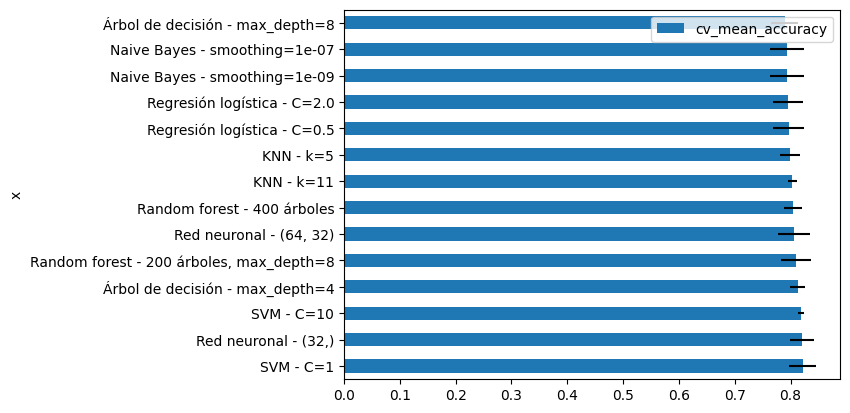

In [17]:
resultados_df.sort_values(by='cv_mean_accuracy', ascending=False).plot(kind='barh', x='x', y='cv_mean_accuracy', xerr='cv_std_accuracy', rot=0)

## 7) Comparar resultados

In [ ]:
# Ordenamos por la primera métrica elegida para facilitar la lectura.
metrica_principal = metricas_seleccionadas[0]
columnas = ["modelo", "version"]
for metrica in metricas_seleccionadas:
    columnas.extend([f"cv_mean_{metrica}", f"cv_std_{metrica}", f"holdout_{metrica}", f"gap_{metrica}"])

comparacion = resultados_df[columnas].sort_values(by=f"cv_mean_{metrica_principal}", ascending=False)
comparacion


In [ ]:
# Una visualización simple ayuda a ver si el rendimiento del holdout sigue la misma historia que la CV.
plt.figure(figsize=(12, 6))
sns.barplot(data=comparacion, x="modelo", y=f"cv_mean_{metrica_principal}", hue="version")
plt.title(f"Comparación por CV según {metrica_principal}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
